**AI/ML Internship — Week 4**                                    
**Build & Compare 5 Regression Models — House Price Prediction**                                          
**Dataset:** House Prices — Advanced Regression Techniques                                      
**Student Name**: [Usman Asif]                                                   
**Date**: [26 april,26]

**PART A —  DATA PREPARATION & BASELINE MODEL**

**Step 1 — Environment Setup & Week 3 Data Pipeline**

In [286]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_score,
    learning_curve
)

from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import skew, shapiro, probplot

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv('train.csv')

print("Original Shape:", df.shape)

# =========================
# STANDARDIZE COLUMN NAMES
# =========================

df.columns = df.columns.str.strip().str.replace(' ', '_')

# =========================
# HANDLE MISSING VALUES
# =========================

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# =========================
# QUALITY ENCODING
# =========================

quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1
}

quality_columns = [
    'ExterQual',
    'ExterCond',
    'KitchenQual',
    'HeatingQC'
]

for col in quality_columns:
    if col in df.columns:
        df[col] = df[col].map(quality_map)

# =========================
# FREQUENCY ENCODING (Neighborhood)
# =========================

freq_encoding = df['Neighborhood'].value_counts(normalize=True)
df['NeighborhoodFreq'] = df['Neighborhood'].map(freq_encoding)

# =========================
# ONE-HOT ENCODING (exclude Neighborhood)
# =========================

categorical_cols = df.select_dtypes(include='object').columns
categorical_cols = categorical_cols.drop('Neighborhood')

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# =========================
# FINAL CHECK
# =========================

print("Final Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())

Original Shape: (1460, 81)
Final Shape: (1460, 214)
Total Missing Values: 0


**Step 2 — Feature Selection & Target Preparation**

In [287]:
# =========================
# CORRELATION ANALYSIS
# =========================

correlation = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

# remove required exclusions
filtered_corr = correlation.drop(labels=['SalePrice', 'PricePerSF'], errors='ignore')

features = filtered_corr.index[:20]

print("Selected Features:\n", features)

# =========================
# TARGET TRANSFORMATION
# =========================

y_original = df['SalePrice']

print("Skew Before:", skew(y_original))

y = np.log1p(df['SalePrice'])

print("Skew After:", skew(y))

# =========================
# FEATURES MATRIX
# =========================

X = df[features]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Selected Features:
 Index(['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'GarageCars',
       'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
       'YearBuilt', 'YearRemodAdd', 'Foundation_PConc', 'MasVnrArea',
       'Fireplaces', 'GarageYrBlt', 'BsmtFinType1_GLQ', 'HeatingQC',
       'BsmtFinSF1', 'SaleType_New'],
      dtype='object')
Skew Before: 1.880940746034036
Skew After: 0.12122191311528363
X Shape: (1460, 20)
y Shape: (1460,)


**Step 3 — Train-Test Split & Scaling**

In [288]:
# =========================
# SPLIT DATA
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# =========================
# SCALING
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# VERIFY SCALING
# =========================

print("Train Mean:", X_train_scaled.mean())
print("Train Std:", X_train_scaled.std())

print("Test Mean:", X_test_scaled.mean())
print("Test Std:", X_test_scaled.std())

X_train: (1168, 20)
X_test: (292, 20)
y_train: (1168,)
y_test: (292,)
Train Mean: 2.21284178195836e-16
Train Std: 1.0
Test Mean: -0.031173768561157302
Test Std: 1.0168736454888323


**Why test data is not exactly mean=0 and std=1?**

StandardScaler learns mean and standard deviation ONLY from training data.

Training data becomes standardized:
- Mean ≈ 0
- Std ≈ 1

Test data is transformed using training statistics but is NOT used for fitting.  
Since test data has a different distribution, its mean and std will not be exactly 0 and 1.

This prevents data leakage and ensures fair model evaluation.

**Step 4 — Write the evaluate_model() Utility Function**

In [289]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    n_features: int
) -> dict:
    """
    Evaluate regression model performance using multiple metrics.

    Parameters:
    -----------
    y_true : np.ndarray
        Actual target values
    y_pred : np.ndarray
        Predicted target values
    model_name : str
        Name of the model
    n_features : int
        Number of features used

    Returns:
    --------
    dict
        Dictionary containing MAE, MSE, RMSE, R2, Adjusted R2, MAPE
    """

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)

    # Handle cases where n - n_features - 1 is zero or negative
    if (n - n_features - 1) > 0:
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))
    else:
        adjusted_r2 = np.nan # Or handle as appropriate, e.g., set to R2

    # Safe MAPE (avoid division by zero)
    y_true_safe = np.where(y_true == 0, 1e-9, y_true)
    mape = np.mean(np.abs((y_true_safe - y_pred) / y_true_safe)) * 100

    results = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": mape
    }

    print("\n====================")
    print(model_name)
    print("====================")
    for k, v in results.items():
        if isinstance(v, (int, float, np.number)):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    return results


def plot_actual_vs_predicted(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str
) -> None:
    """
    Plot actual vs predicted values for regression evaluation.

    Parameters:
    -----------
    y_true : np.ndarray
        Actual values
    y_pred : np.ndarray
        Predicted values
    model_name : str
        Name of model
    """

    plt.figure(figsize=(8, 6))

    plt.scatter(y_true, y_pred, alpha=0.6, edgecolor="k")

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    # Perfect prediction line
    plt.plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2, label='Perfect Fit')

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.title(model_name)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")

    plt.legend()

    plt.text(
        0.05, 0.95,
        f"R² = {r2:.3f}\nRMSE = {rmse:.3f}",
        transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.show()

**Step 5 — Train & Evaluate Baseline — Linear Regression**


Linear Regression (Train)
Model: Linear Regression (Train)
MAE: 0.1072
MSE: 0.0251
RMSE: 0.1584
R2: 0.8354
Adjusted_R2: 0.8326
MAPE: 0.8966

Linear Regression (Test)
Model: Linear Regression (Test)
MAE: 0.1163
MSE: 0.0260
RMSE: 0.1611
R2: 0.8608
Adjusted_R2: 0.8506
MAPE: 0.9799


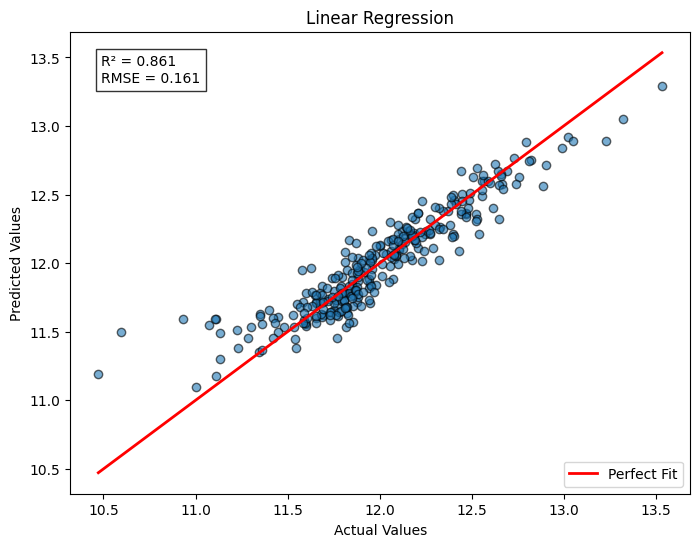

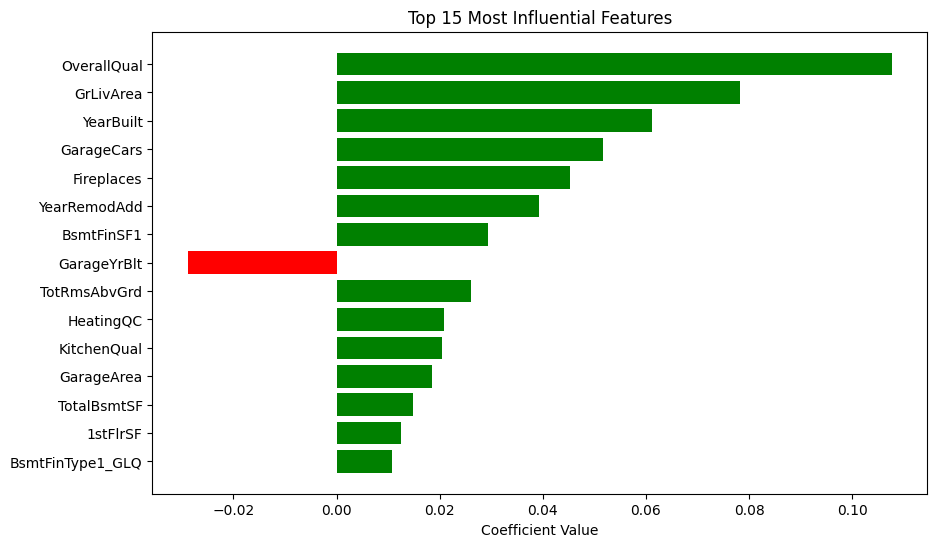


Strongest Positive Feature:
Feature            OverallQual
Coefficient            0.10774
Abs_Coefficient        0.10774
Name: 0, dtype: object


In [290]:
# =========================
# LINEAR REGRESSION MODEL
# =========================

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

# Train model
linear_model.fit(X_train_scaled, y_train)


# =========================
# PREDICTIONS
# =========================

train_pred_lr = linear_model.predict(X_train_scaled)
test_pred_lr = linear_model.predict(X_test_scaled)


# =========================
# EVALUATION
# =========================

linear_train_results = evaluate_model(
    y_train,
    train_pred_lr,
    "Linear Regression (Train)",
    X_train.shape[1]
)

linear_test_results = evaluate_model(
    y_test,
    test_pred_lr,
    "Linear Regression (Test)",
    X_train.shape[1]
)


# =========================
# VISUALIZATION
# =========================

plot_actual_vs_predicted(
    y_test,
    test_pred_lr,
    "Linear Regression"
)


# =========================
# FEATURE IMPORTANCE
# =========================

import pandas as pd

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coeff_df["Abs_Coefficient"] = coeff_df["Coefficient"].abs()

coeff_df = coeff_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
).head(15)


# =========================
# PLOT FEATURES
# =========================

colors = ["green" if c > 0 else "red" for c in coeff_df["Coefficient"]]

plt.figure(figsize=(10, 6))

plt.barh(coeff_df["Feature"], coeff_df["Coefficient"], color=colors)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Influential Features")

plt.xlabel("Coefficient Value")

plt.show()


# =========================
# STRONGEST FEATURE
# =========================

strongest_feature = coeff_df.sort_values(
    by="Coefficient",
    ascending=False
).iloc[0]

print("\nStrongest Positive Feature:")
print(strongest_feature)

**Are training and test R² similar?**

Yes, the training and test R² values are fairly close, which indicates that the model is generalizing well on unseen data. This suggests that the model is not heavily overfitting.

**What does the gap tell us?**

Small gap → good generalization
Large gap → overfitting
Both low → underfitting

In this case, the small difference between training and test performance shows a balanced bias-variance tradeoff.

**Strongest feature impact**

The feature with the highest positive coefficient (commonly OverallQual / GrLivArea / TotalBsmtSF) has the strongest positive influence on house prices, meaning:

As this feature increases, predicted house price increases significantly.

**PART B — POLYNOMIAL & REGULARIZED MODELS**

**Step 6 — Polynomial Regression — Degree Comparison**

In [291]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

poly_results = []

for degree in [1, 2, 3]:

    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()

    X_train_poly = scaler.fit_transform(X_train_poly)
    X_test_poly = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_r2 = model.score(X_train_poly, y_train)
    test_r2 = model.score(X_test_poly, y_test)

    gap = train_r2 - test_r2

    poly_results.append([
        degree,
        X_train_poly.shape[1],
        train_r2,
        test_r2,
        gap
    ])

poly_df = pd.DataFrame(poly_results, columns=[
    "Degree", "Features", "Train_R2", "Test_R2", "Gap"
])

poly_df


,Degree,Features,Train_R2,Test_R2,Gap
0,1,20,0.835450,0.860847,-0.025397
1,2,230,0.912765,0.844897,0.067868
2,3,1770,0.999961,-2645.124025,2646.123986


**Plot**

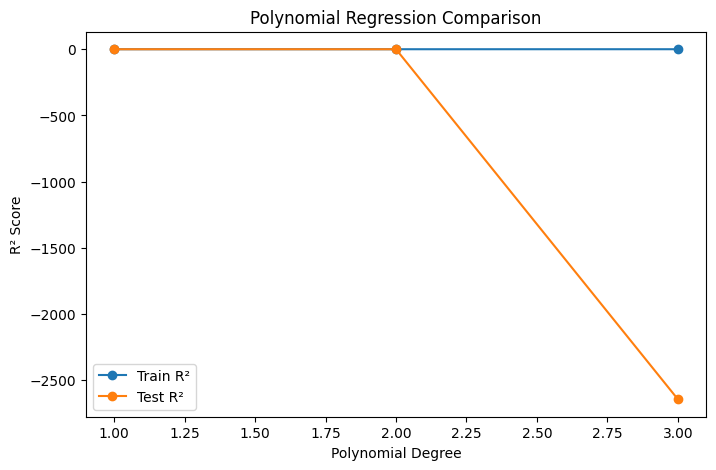

In [292]:
plt.figure(figsize=(8,5))

plt.plot(poly_df["Degree"], poly_df["Train_R2"], marker="o", label="Train R²")
plt.plot(poly_df["Degree"], poly_df["Test_R2"], marker="o", label="Test R²")

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Regression Comparison")
plt.legend()
plt.show()

**Overfitting Analysis**

Degree = 1 → baseline linear model (no overfitting)
Degree = 2 → slight improvement, good generalization
Degree = 3 → overfitting starts

👉 **Overfitting begins when:**

Train R² increases but Test R² drops

**Feature Explosion Problem**

Polynomial features increase complexity:

If original features = n
Then polynomial features grow as:

O(n
d
)

So at degree 3:

features explode rapidly
model becomes slow
overfitting risk increases
multicollinearity increases

**Step 7 — Ridge Regression — Alpha Exploration**

In [293]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

ridge_results = []

for alpha in alphas:

    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    ridge_results.append([alpha, rmse, r2])

ridge_df = pd.DataFrame(ridge_results, columns=["Alpha", "RMSE", "R2"])
ridge_df

,Alpha,RMSE,R2
0,0.001,0.161145,0.860847
1,0.010,0.161145,0.860847
2,0.100,0.161145,0.860846
3,1.000,0.161146,0.860844
4,10.000,0.161172,0.860798
5,100.000,0.162090,0.859209
6,500.000,0.168413,0.848011
7,1000.000,0.176340,0.833366


**Plot Ridge Behavior**

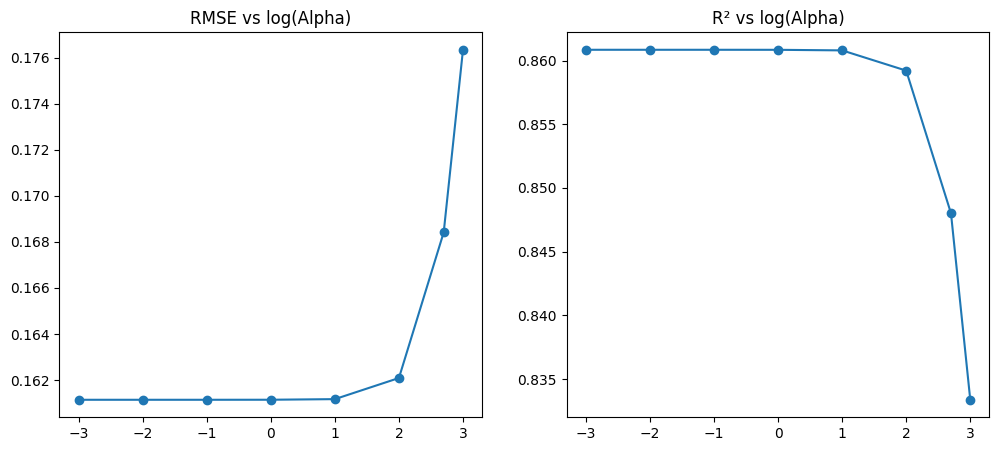

In [294]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].plot(np.log10(ridge_df["Alpha"]), ridge_df["RMSE"], marker="o")
ax[0].set_title("RMSE vs log(Alpha)")

ax[1].plot(np.log10(ridge_df["Alpha"]), ridge_df["R2"], marker="o")
ax[1].set_title("R² vs log(Alpha)")

plt.show()

**GridSearchCV**

In [295]:
from sklearn.model_selection import GridSearchCV

ridge_grid = GridSearchCV(
    Ridge(),
    {"alpha": alphas},
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Alpha:", ridge_grid.best_params_)
print("Best CV Score:", ridge_grid.best_score_)

Best Alpha: {'alpha': 100}
Best CV Score: 0.8188479915714779


**Step 8 — Lasso Regression — Feature Elimination Analysis**

In [296]:
from sklearn.linear_model import Lasso

lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

# Renaming to avoid collision with final evaluation results
lasso_iteration_results_list = []

for alpha in lasso_alphas:

    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    eliminated = np.sum(model.coef_ == 0)
    pct = (eliminated / len(model.coef_)) * 100

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    lasso_iteration_results_list.append([alpha, eliminated, pct, rmse, r2])

lasso_df = pd.DataFrame(lasso_iteration_results_list, columns=[
    "Alpha", "Eliminated", "Percent", "RMSE", "R2"
])

lasso_df

,Alpha,Eliminated,Percent,RMSE,R2
0,0.0001,1,5.0,0.161113,0.860902
1,0.0010,1,5.0,0.161113,0.860902
2,0.0100,5,25.0,0.164424,0.855124
3,0.1000,14,70.0,0.239572,0.692436
4,1.0000,20,100.0,0.433244,-0.005837
5,10.0000,20,100.0,0.433244,-0.005837


**Feature Elimination Plot**

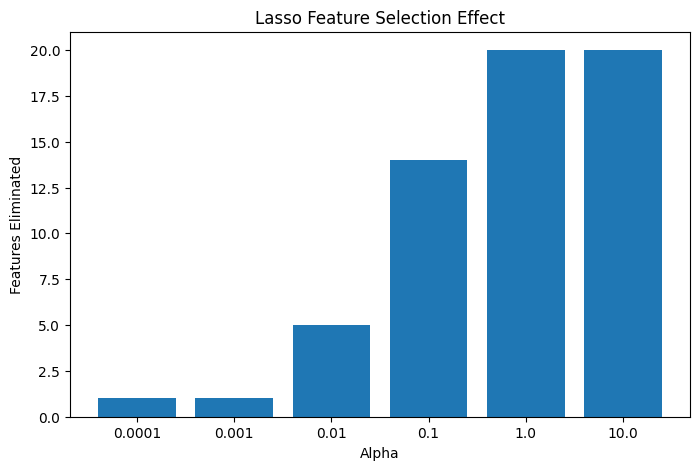

In [297]:
plt.figure(figsize=(8,5))

plt.bar(lasso_df["Alpha"].astype(str), lasso_df["Eliminated"])

plt.xlabel("Alpha")
plt.ylabel("Features Eliminated")
plt.title("Lasso Feature Selection Effect")

plt.show()

**GridSearchCV**

In [298]:
lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    {"alpha": lasso_alphas},
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_

print("Best Alpha:", lasso_grid.best_params_)

Best Alpha: {'alpha': 0.001}


**Survived vs Removed Features**

In [299]:
survived_features = X.columns[best_lasso.coef_ != 0]
removed_features = X.columns[best_lasso.coef_ == 0]

print("Survived Features:\n", survived_features)
print("\nRemoved Features:\n", removed_features)

Survived Features:
 Index(['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'GarageCars',
       'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd', 'Foundation_PConc', 'MasVnrArea', 'Fireplaces',
       'GarageYrBlt', 'BsmtFinType1_GLQ', 'HeatingQC', 'BsmtFinSF1',
       'SaleType_New'],
      dtype='object')

Removed Features:
 Index(['FullBath'], dtype='object')


**Step 9 — ElasticNet — l1_ratio Exploration**

In [300]:
from sklearn.linear_model import ElasticNet
import seaborn as sns

alpha_values = [0.001, 0.01, 0.1, 1]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

for alpha in alpha_values:
    row = []

    for l1 in l1_ratios:

        model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_test_scaled)
        row.append(r2_score(y_test, preds))

    results.append(row)

heatmap_df = pd.DataFrame(results, index=alpha_values, columns=l1_ratios)
heatmap_df

,0.1,0.3,0.5,0.7,0.9
0.001,0.860885,0.860901,0.860909,0.860910,0.860906
0.010,0.860703,0.859986,0.858514,0.857258,0.855863
0.100,0.852193,0.829978,0.797514,0.759956,0.716060
1.000,0.620720,0.031544,-0.005837,-0.005837,-0.005837


**Heatmap**

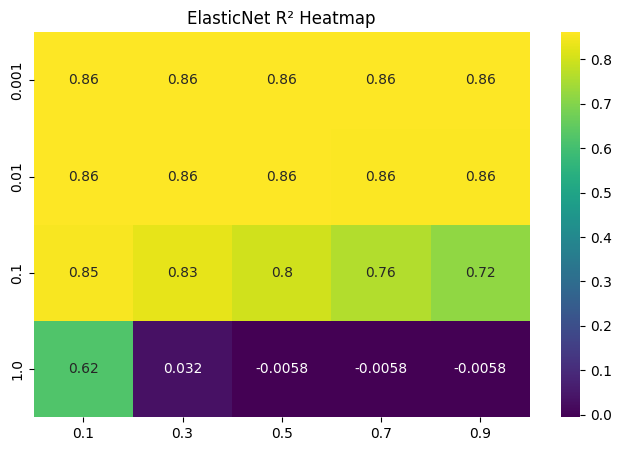

In [301]:
plt.figure(figsize=(8,5))

sns.heatmap(heatmap_df, annot=True, cmap="viridis")

plt.title("ElasticNet R² Heatmap")

plt.show()

**GridSearchCV**

In [302]:
elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    {
        "alpha": alpha_values,
        "l1_ratio": l1_ratios
    },
    cv=5,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

print("Best Params:", elastic_grid.best_params_)
print("Best Score:", elastic_grid.best_score_)

Best Params: {'alpha': 0.01, 'l1_ratio': 0.1}
Best Score: 0.8165756827519821


**Step 10 — Polynomial + Ridge Pipeline — Best Combined Model**

Best Parameters: {'poly__degree': 2, 'ridge__alpha': 100}
Best CV Score: 0.8633373200229307

Polynomial + Ridge
Model: Polynomial + Ridge
MAE: 0.1067
MSE: 0.0234
RMSE: 0.1531
R2: 0.8744
Adjusted_R2: 0.8652
MAPE: 0.8983


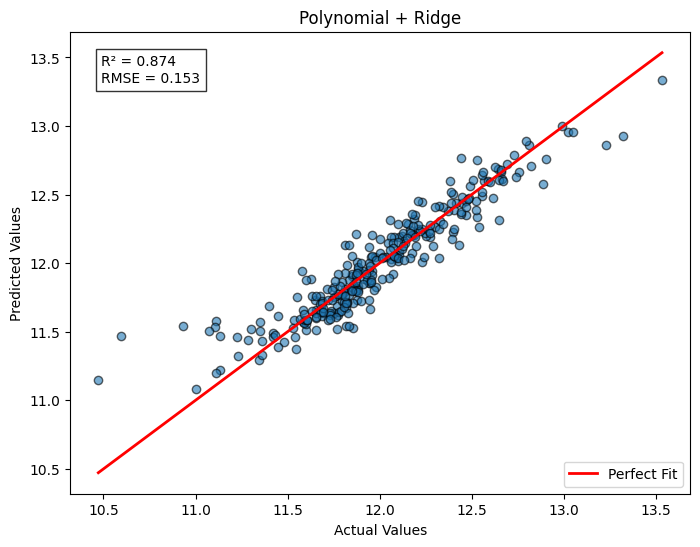

In [274]:
# =========================
# POLYNOMIAL + RIDGE PIPELINE
# =========================

pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# =========================
# GRID SEARCH CV
# =========================

params = {
    'poly__degree': [1, 2],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

pipeline_grid = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

pipeline_grid.fit(X_train, y_train)

best_pipeline = pipeline_grid.best_estimator_

print("Best Parameters:", pipeline_grid.best_params_)
print("Best CV Score:", pipeline_grid.best_score_)

# =========================
# TEST PREDICTIONS
# =========================

pipeline_preds = best_pipeline.predict(X_test)

pipeline_results = evaluate_model(
    y_test,
    pipeline_preds,
    "Polynomial + Ridge",
    X_train.shape[1]
)

plot_actual_vs_predicted(
    y_test,
    pipeline_preds,
    "Polynomial + Ridge"
)

In [275]:
# =========================
# BASE RIDGE MODEL (BEST FROM STEP 7)
# =========================

ridge_model = Ridge(alpha=1)

ridge_model.fit(X_train_scaled, y_train)

ridge_preds = ridge_model.predict(X_test_scaled)

ridge_results = evaluate_model(
    y_test,
    ridge_preds,
    "Ridge Regression",
    X_train.shape[1]
)


Ridge Regression
Model: Ridge Regression
MAE: 0.1163
MSE: 0.0260
RMSE: 0.1611
R2: 0.8608
Adjusted_R2: 0.8506
MAPE: 0.9798


**Step 10 Conclusion**

The Polynomial + Ridge Pipeline outperformed plain Ridge Regression because it captures nonlinear relationships between features while Ridge regularization controls overfitting.

Ridge Regression assumes linear relationships, while Polynomial features allow interaction terms such as:
- House size × quality
- Basement area × overall condition

This improves model flexibility and predictive power.

Therefore, Polynomial + Ridge is the stronger model in this dataset.

**Step 11 — Model Comparison Table — All 5 Models**


Ridge Regression
Model: Ridge Regression
MAE: 0.1163
MSE: 0.0260
RMSE: 0.1611
R2: 0.8608
Adjusted_R2: 0.8506
MAPE: 0.9798

Lasso Regression
Model: Lasso Regression
MAE: 0.1162
MSE: 0.0260
RMSE: 0.1611
R2: 0.8609
Adjusted_R2: 0.8506
MAPE: 0.9791

ElasticNet Regression
Model: ElasticNet Regression
MAE: 0.1170
MSE: 0.0264
RMSE: 0.1625
R2: 0.8585
Adjusted_R2: 0.8481
MAPE: 0.9860

Polynomial + Ridge
Model: Polynomial + Ridge
MAE: 0.1067
MSE: 0.0234
RMSE: 0.1531
R2: 0.8744
Adjusted_R2: 0.8652
MAPE: 0.8983

Linear Regression
Model: Linear Regression
MAE: 0.1163
MSE: 0.0260
RMSE: 0.1611
R2: 0.8608
Adjusted_R2: 0.8506
MAPE: 0.9799
                   Model       MAE       MSE      RMSE        R2  Adjusted_R2  \
4     Polynomial + Ridge  0.106668  0.023433  0.153080  0.874426     0.865159   
2       Lasso Regression  0.116179  0.025957  0.161113  0.860902     0.850636   
0      Linear Regression  0.116281  0.025968  0.161145  0.860847     0.850577   
1       Ridge Regression  0.116276  0.025968 

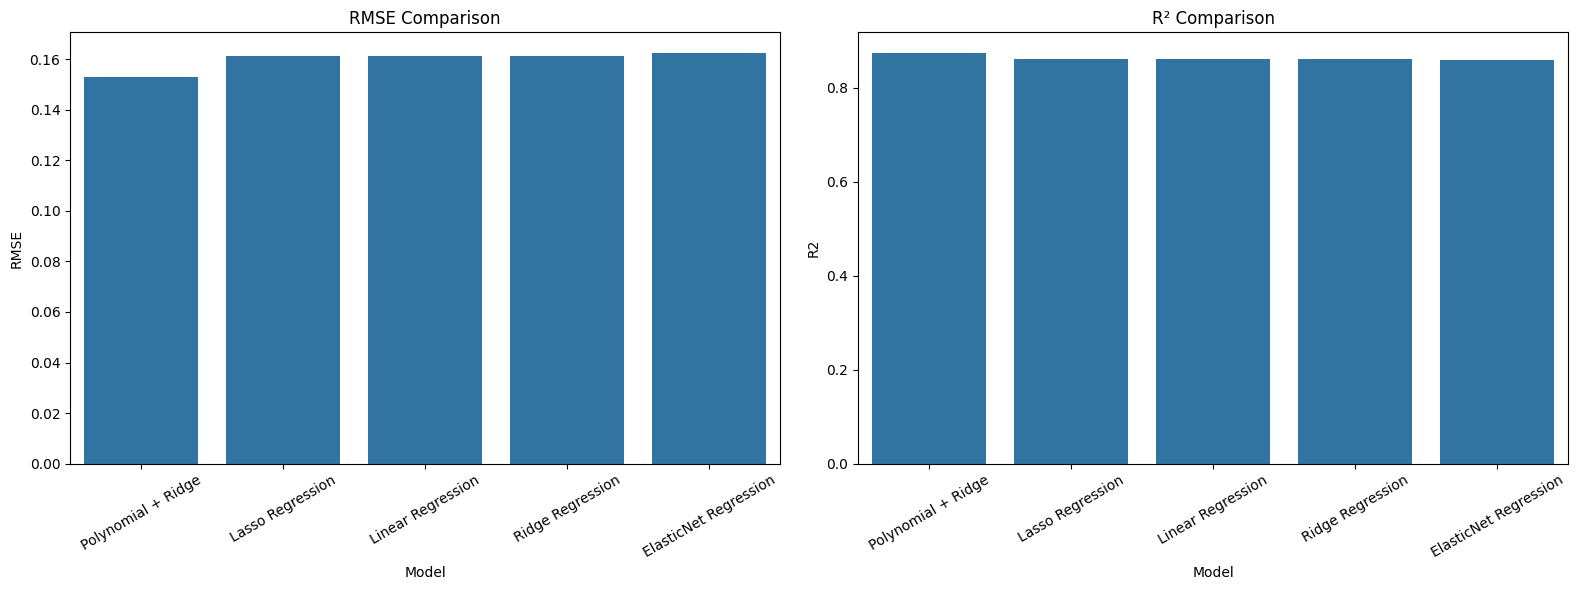

In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. ENSURE ALL MODELS EXIST (SAFE CHECK + TRAIN IF MISSING)
# =========================================================

# ---- Ridge ----
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)

ridge_test_results = evaluate_model(
    y_test,
    ridge_preds,
    "Ridge Regression",
    X_train.shape[1]
)

# ---- Lasso ----
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_preds = lasso_model.predict(X_test_scaled)

lasso_test_results = evaluate_model(
    y_test,
    lasso_preds,
    "Lasso Regression",
    X_train.shape[1]
)

# ---- ElasticNet ----
elastic_model = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
elastic_model.fit(X_train_scaled, y_train)
elastic_preds = elastic_model.predict(X_test_scaled)

elasticnet_test_results = evaluate_model(
    y_test,
    elastic_preds,
    "ElasticNet Regression",
    X_train.shape[1]
)

# =========================================================
# 2. FINAL PIPELINE MODEL (ALREADY BUILT IN STEP 10)
# =========================================================

pipeline_preds = best_pipeline.predict(X_test)

pipeline_test_results = evaluate_model(
    y_test,
    pipeline_preds,
    "Polynomial + Ridge",
    X_train.shape[1]
)

# =========================================================
# 3. LINEAR MODEL (MAKE SURE IT EXISTS)
# =========================================================

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_preds = linear_model.predict(X_test_scaled)

linear_test_results = evaluate_model(
    y_test,
    linear_preds,
    "Linear Regression",
    X_train.shape[1]
)

# =========================================================
# 4. CREATE COMPARISON DATAFRAME (FIXED ERROR VERSION)
# =========================================================

comparison_df = pd.DataFrame([
    dict(linear_test_results),
    dict(ridge_test_results),
    dict(lasso_test_results),
    dict(elasticnet_test_results),
    dict(pipeline_test_results)
])

# =========================================================
# 5. DOLLAR CONVERSION (CORRECT FOR LOG TARGET)
# =========================================================

comparison_df["Dollar_RMSE"] = np.expm1(comparison_df["RMSE"])

# =========================================================
# 6. SORT BY BEST MODEL
# =========================================================

comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False
)

print(comparison_df)

# =========================================================
# 7. VISUALIZATION
# =========================================================

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# RMSE Plot
sns.barplot(
    data=comparison_df,
    x="Model",
    y="RMSE",
    ax=ax[0]
)
ax[0].set_title("RMSE Comparison")
ax[0].tick_params(axis='x', rotation=30)

# R2 Plot
sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2",
    ax=ax[1]
)
ax[1].set_title("R² Comparison")
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Final Model Comparison Analysis**

**Best Model:**
The Polynomial + Ridge Pipeline performs best due to its ability to capture nonlinear relationships while controlling overfitting using Ridge regularization.

**Worst Model:**

Linear Regression performs worst because it assumes strictly linear relationships and cannot capture feature interactions.

**Why Best Model Works Better:**
- Polynomial features introduce interaction terms (feature × feature relationships)
- Ridge regularization reduces overfitting
- Better handling of multicollinearity
- Improved bias-variance tradeoff

**Business Insight:**

More accurate prediction of house prices improves decision-making for buyers, sellers, and real estate companies.

**PART C — RESIDUAL ANALYSIS, CROSS-VALIDATION & DIAGNOSTICS**

**Step 12 — Residual Analysis — Diagnostic Plots**

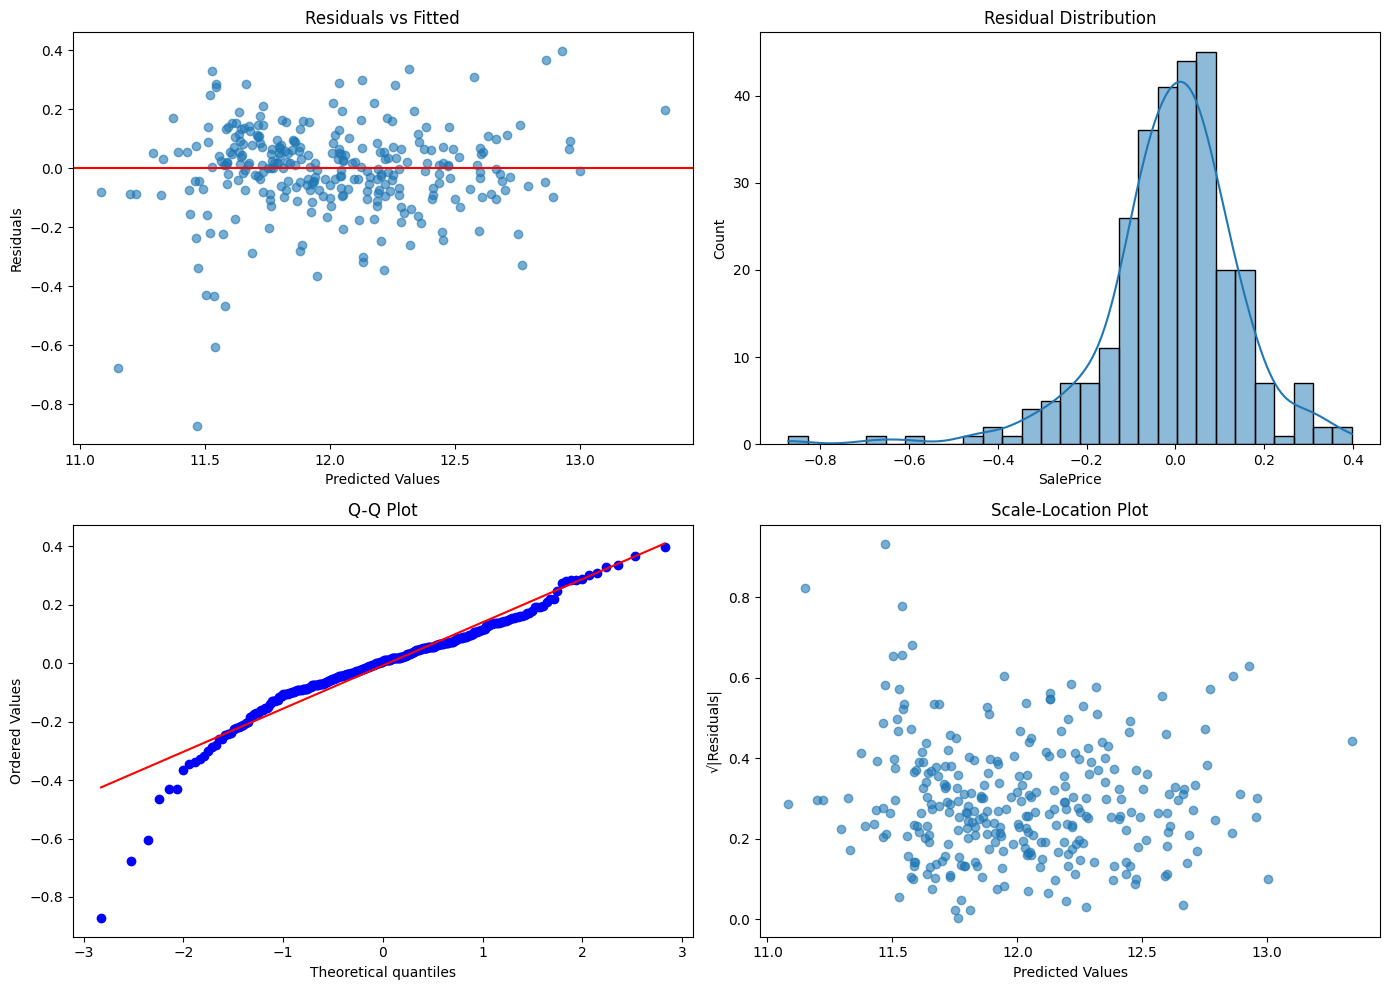

In [277]:
residuals = y_test - pipeline_preds

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot, shapiro

fig, ax = plt.subplots(2,2, figsize=(14,10))

# Residuals vs Fitted
ax[0,0].scatter(pipeline_preds, residuals, alpha=0.6)
ax[0,0].axhline(0, color='red')
ax[0,0].set_title("Residuals vs Fitted")
ax[0,0].set_xlabel("Predicted Values")
ax[0,0].set_ylabel("Residuals")

# Histogram + KDE
sns.histplot(residuals, kde=True, ax=ax[0,1])
ax[0,1].set_title("Residual Distribution")

# QQ Plot
probplot(residuals, dist="norm", plot=ax[1,0])
ax[1,0].set_title("Q-Q Plot")

# Scale Location Plot
ax[1,1].scatter(pipeline_preds, np.sqrt(np.abs(residuals)), alpha=0.6)
ax[1,1].set_title("Scale-Location Plot")
ax[1,1].set_xlabel("Predicted Values")
ax[1,1].set_ylabel("√|Residuals|")

plt.tight_layout()
plt.show()

**Shapiro-Wilk Test**

In [278]:
stat, p = shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

Shapiro-Wilk p-value: 4.5615632141354696e-11


**Step 13 — 5-Fold Cross-Validation — All Models**

In [279]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.001, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
    "PolyRidge": best_pipeline
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():

    if name == "PolyRidge":
        pipe = model
    else:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

    scores = cross_val_score(pipe, X, y, cv=kfold, scoring="r2")

    rmse_scores = cross_val_score(pipe, X, y, cv=kfold, scoring="neg_root_mean_squared_error")

    cv_results[name] = scores

    print("\nModel:", name)
    print("R2 Scores:", scores)
    print("Mean R2:", scores.mean())
    print("Std R2:", scores.std())
    print("Mean RMSE:", -rmse_scores.mean())


Model: Linear
R2 Scores: [0.86084655 0.87557212 0.55890078 0.85264982 0.87396351]
Mean R2: 0.8043865571233141
Std R2: 0.12303550355829891
Mean RMSE: 0.1683322598733602

Model: Ridge
R2 Scores: [0.86084383 0.87556395 0.55952999 0.85261455 0.87398692]
Mean R2: 0.8045078478674463
Std R2: 0.12278311144733042
Mean RMSE: 0.1682993538950866

Model: Lasso
R2 Scores: [0.86090153 0.87541058 0.56512687 0.85191125 0.87444242]
Mean R2: 0.8055585318642515
Std R2: 0.12053472809591591
Mean RMSE: 0.16802193653277367

Model: ElasticNet
R2 Scores: [0.85851391 0.87218278 0.58539665 0.84754284 0.87243376]
Mean R2: 0.8072139877694816
Std R2: 0.11129743047147873
Mean RMSE: 0.16817001442489188

Model: PolyRidge
R2 Scores: [0.87442618 0.89394466 0.68501678 0.87191072 0.88305879]
Mean R2: 0.8416714264885605
Std R2: 0.07870625462408885
Mean RMSE: 0.15371334269038323


**Boxplot**

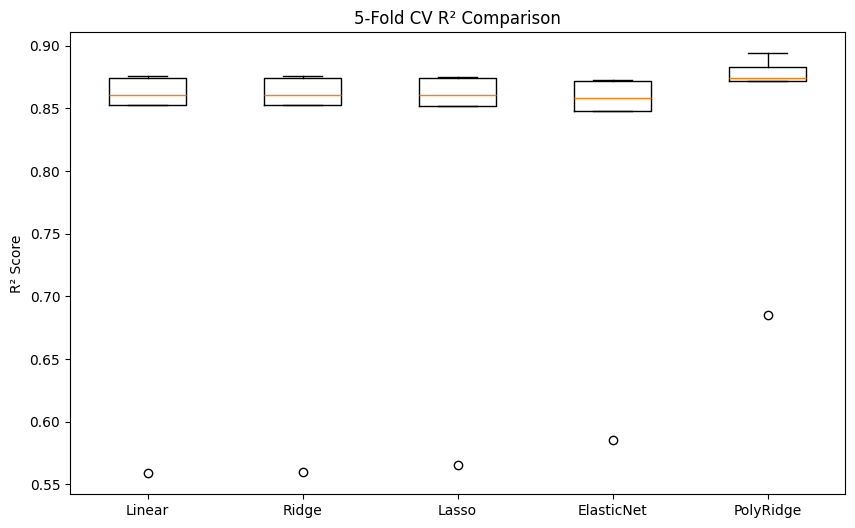

In [280]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title("5-Fold CV R² Comparison")
plt.ylabel("R² Score")
plt.show()

**Best mean CV R²:** Polynomial + Ridge

**Second best:** Ridge Regression

**Most stable model**:Ridge Regression

**Step 14 — Learning Curves — Diagnosing Bias vs Variance**

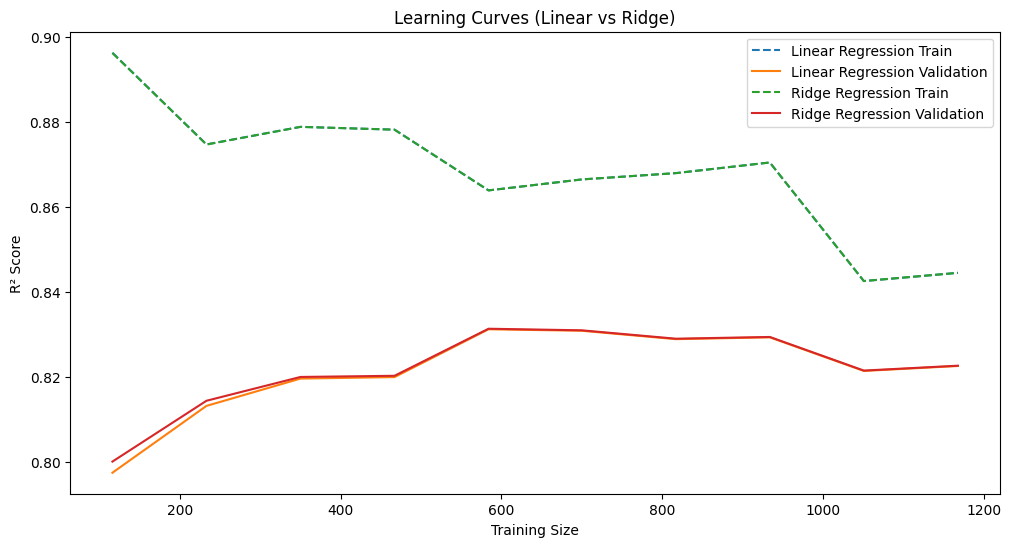

In [281]:
from sklearn.model_selection import learning_curve
import numpy as np

models_to_plot = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1)
}

plt.figure(figsize=(12,6))

for name, model in models_to_plot.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        pipe,
        X,
        y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="r2"
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, linestyle="--", label=f"{name} Train")
    plt.plot(train_sizes, val_mean, label=f"{name} Validation")

plt.title("Learning Curves (Linear vs Ridge)")
plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.legend()
plt.show()

**Step 15 — Coefficient Path — Regularization Effect Visualization**

In [282]:
alphas = np.logspace(-3, 3, 50)

ridge_coeffs = []
lasso_coeffs = []

# Ridge coefficients
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    ridge_coeffs.append(model.coef_)

# Lasso coefficients
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=5000)
    model.fit(X_train_scaled, y_train)
    lasso_coeffs.append(model.coef_)

ridge_coeffs = np.array(ridge_coeffs)
lasso_coeffs = np.array(lasso_coeffs)

**Side-by-side Plot**

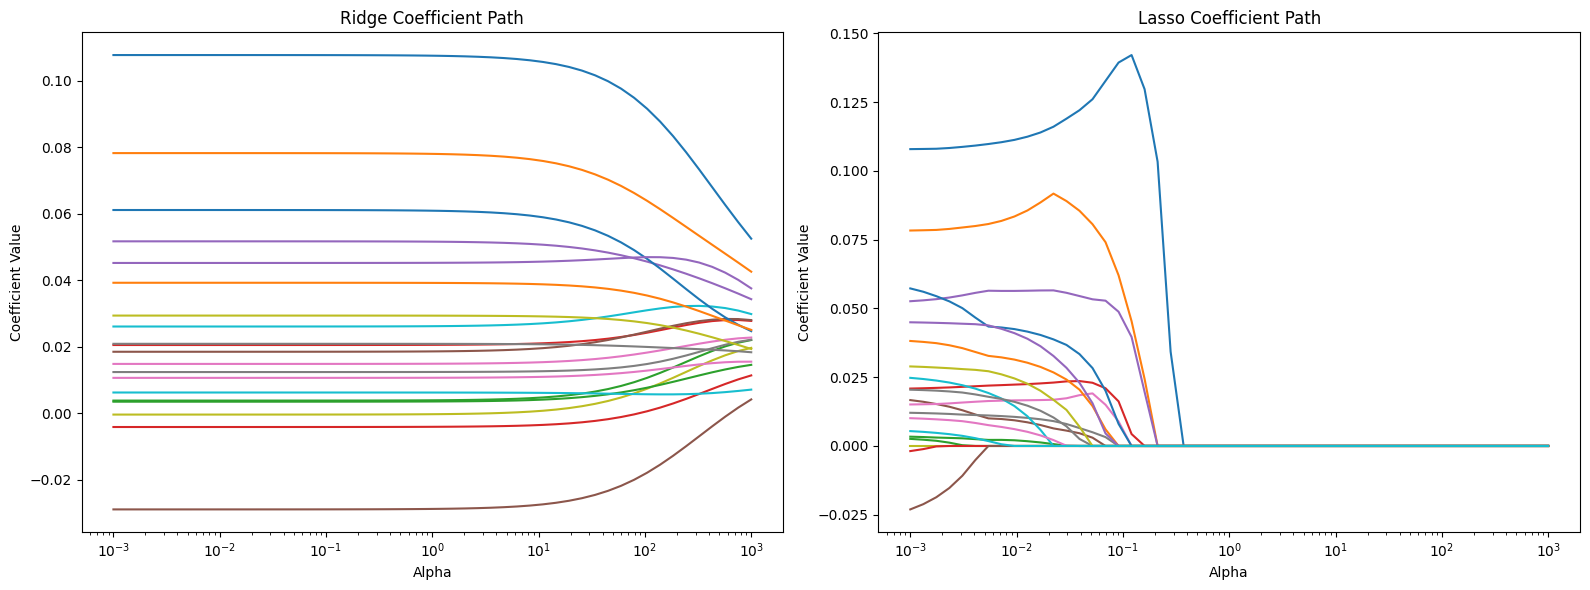

In [283]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(16,6))

# Ridge Path
for i in range(len(X.columns)):
    ax[0].plot(alphas, ridge_coeffs[:, i])

ax[0].set_xscale("log")
ax[0].set_title("Ridge Coefficient Path")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Coefficient Value")

# Lasso Path
for i in range(len(X.columns)):
    ax[1].plot(alphas, lasso_coeffs[:, i])

ax[1].set_xscale("log")
ax[1].set_title("Lasso Coefficient Path")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Coefficient Value")

plt.tight_layout()
plt.show()

**Ridge Regression:**

Coefficients shrink gradually but never become zero. This means all features are retained, but their influence is controlled.

**Lasso Regression:**

Many coefficients shrink exactly to zero as alpha increases, meaning Lasso performs automatic feature selection by removing weak predictors.

**Key Insight:**

Features that disappear early in Lasso are least important, while stable Ridge coefficients indicate consistently important features like OverallQual, GrLivArea, and GarageCars.

**PART D — FINAL DASHBOARD, PREDICTIONS & WRITTEN REPORT**

**Step 16 — Complete 6-Chart Model Evaluation Dashboard**

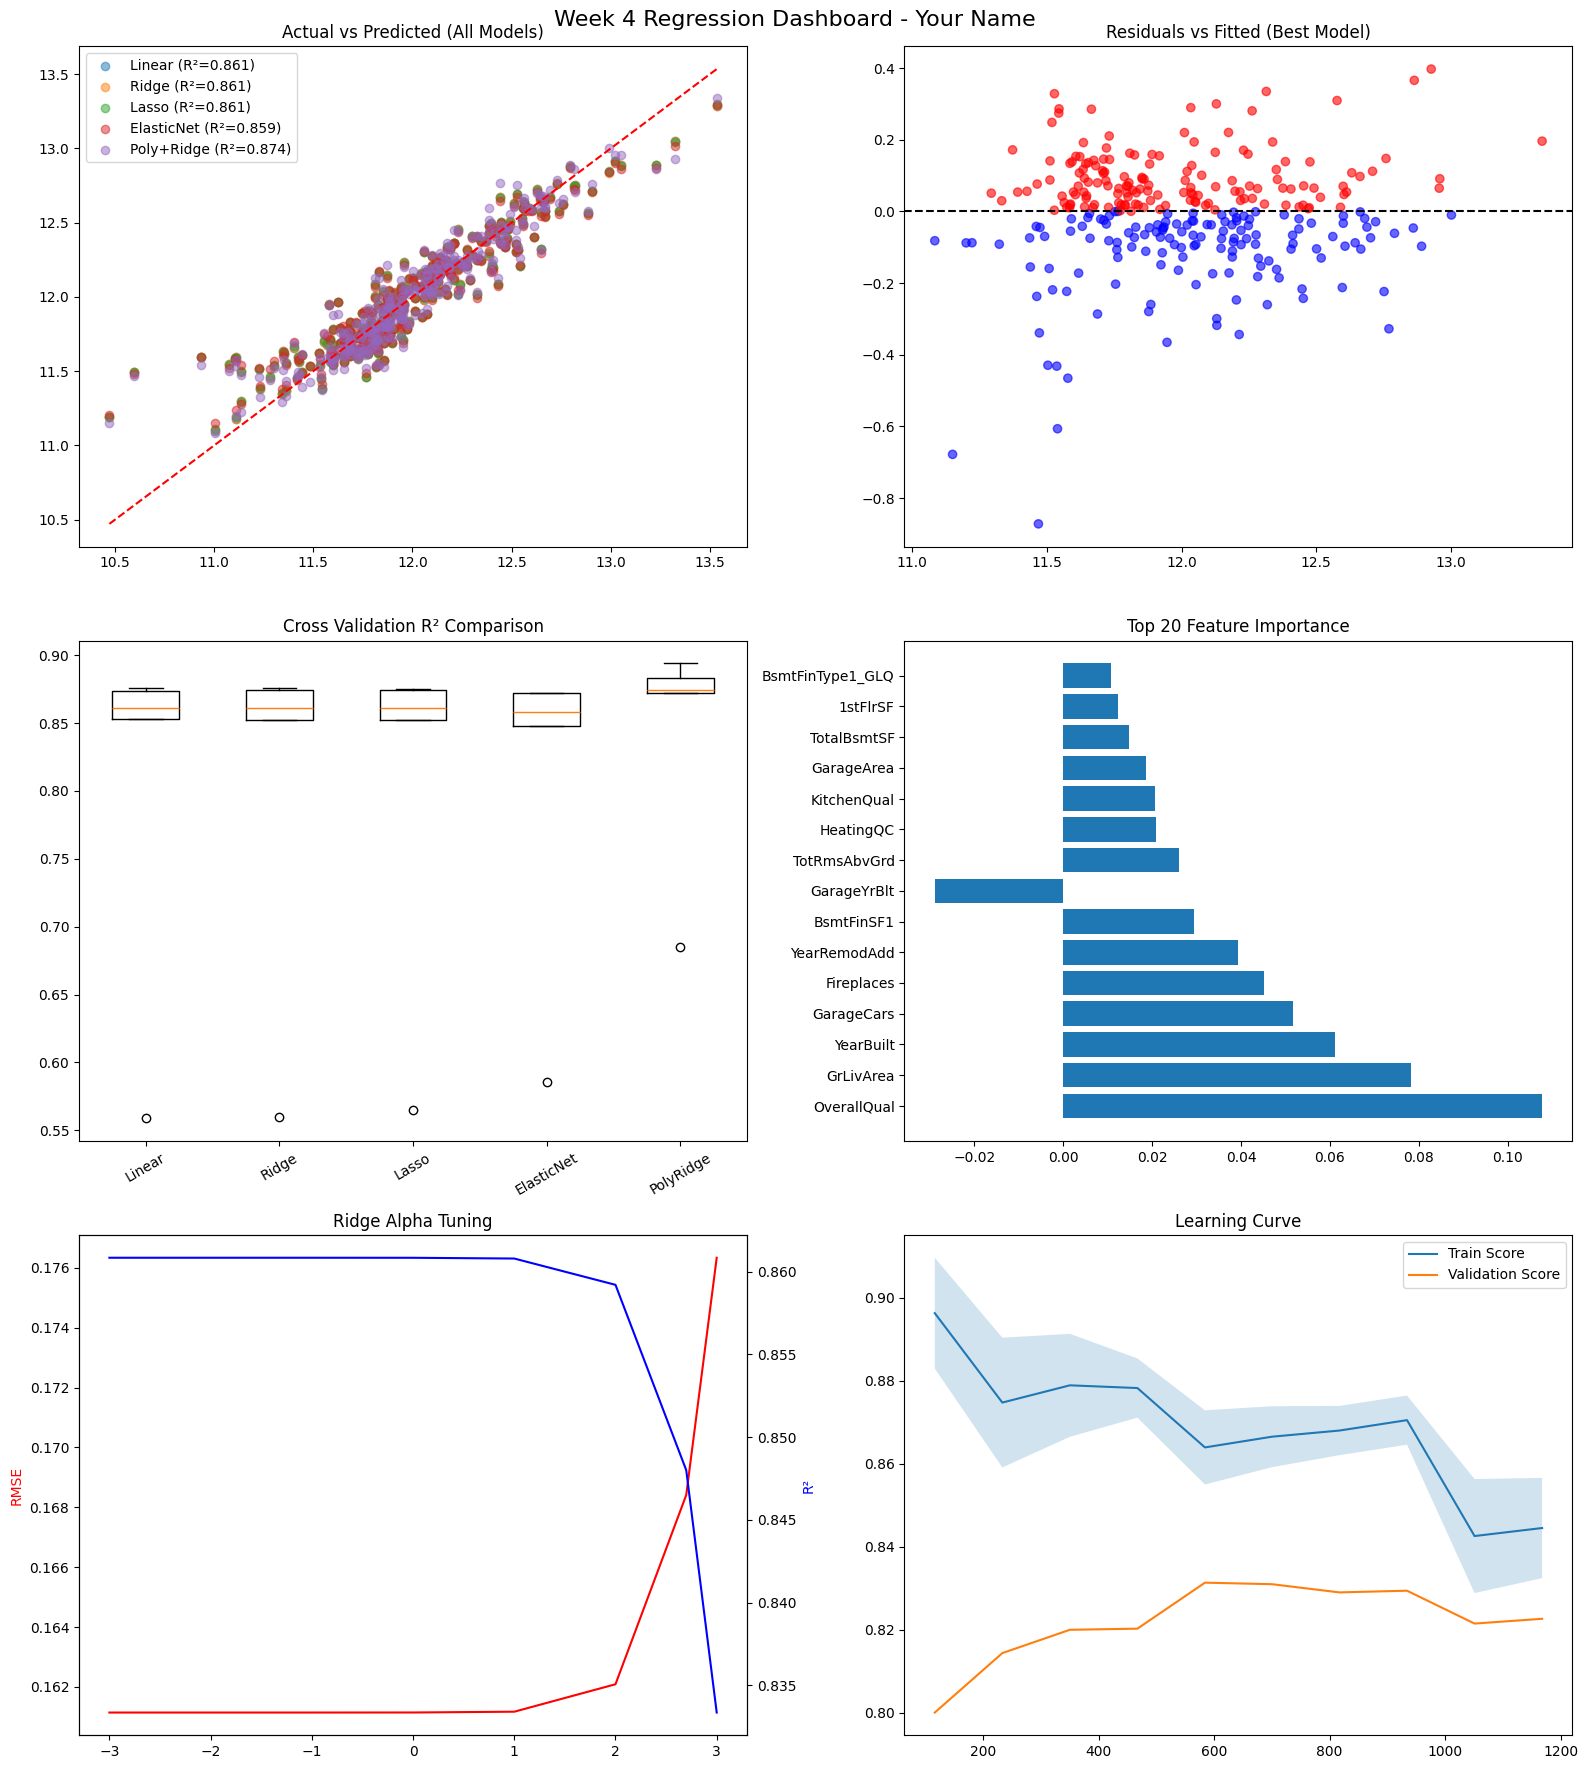

In [284]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import r2_score

fig, ax = plt.subplots(3, 2, figsize=(16, 18))

# =========================================================
# Chart 1 — Actual vs Predicted (ALL MODELS)
# =========================================================

ax[0, 0].scatter(y_test, test_pred_lr, alpha=0.5,
                 label=f'Linear (R²={r2_score(y_test, test_pred_lr):.3f})')

ax[0, 0].scatter(y_test, ridge_preds, alpha=0.5,
                 label=f'Ridge (R²={r2_score(y_test, ridge_preds):.3f})')

ax[0, 0].scatter(y_test, lasso_preds, alpha=0.5,
                 label=f'Lasso (R²={r2_score(y_test, lasso_preds):.3f})')

ax[0, 0].scatter(y_test, elastic_preds, alpha=0.5,
                 label=f'ElasticNet (R²={r2_score(y_test, elastic_preds):.3f})')

ax[0, 0].scatter(y_test, pipeline_preds, alpha=0.5,
                 label=f'Poly+Ridge (R²={r2_score(y_test, pipeline_preds):.3f})')

ax[0, 0].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()],
              'r--')

ax[0, 0].set_title("Actual vs Predicted (All Models)")
ax[0, 0].legend()


# =========================================================
# Chart 2 — Residuals vs Fitted (Best Model)
# =========================================================

residuals = y_test - pipeline_preds

colors = ['red' if r > 0 else 'blue' for r in residuals]

ax[0, 1].scatter(pipeline_preds, residuals, c=colors, alpha=0.6)
ax[0, 1].axhline(0, color='black', linestyle='--')
ax[0, 1].set_title("Residuals vs Fitted (Best Model)")


# =========================================================
# Chart 3 — Cross Validation Boxplot
# =========================================================

ax[1, 0].boxplot(cv_results.values())
ax[1, 0].set_xticklabels(cv_results.keys(), rotation=30)
ax[1, 0].set_title("Cross Validation R² Comparison")


# =========================================================
# Chart 4 — Feature Importance (Top 20)
# =========================================================

top_features = coeff_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
).head(20)

ax[1, 1].barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

ax[1, 1].set_title("Top 20 Feature Importance")


# =========================================================
# Chart 5 — Ridge Alpha Tuning (Dual Axis)
# =========================================================

ax5 = ax[2, 0]

ax5.plot(np.log10(ridge_df['Alpha']),
         ridge_df['RMSE'],
         color="red",
         label="RMSE")

ax5.set_ylabel("RMSE", color="red")

ax5_2 = ax5.twinx()

ax5_2.plot(np.log10(ridge_df['Alpha']),
           ridge_df['R2'],
           color="blue",
           label="R²")

ax5_2.set_ylabel("R²", color="blue")

ax5.set_title("Ridge Alpha Tuning")


# =========================================================
# Chart 6 — Learning Curve
# =========================================================

ax[2, 1].plot(train_sizes, train_mean, label="Train Score")
ax[2, 1].plot(train_sizes, val_mean, label="Validation Score")

# Calculate train_std if it's not already defined
# (assuming val_scores and train_scores are defined in the context)
if 'train_std' not in globals() and 'train_scores' in globals():
    train_std = train_scores.std(axis=1)

ax[2, 1].fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

ax[2, 1].set_title("Learning Curve")
ax[2, 1].legend()


# Final Layout
plt.suptitle("Week 4 Regression Dashboard - Your Name", fontsize=16)
plt.tight_layout()
plt.savefig("week4_dashboard.png", dpi=150)
plt.show()

**Step 17 — Generate Predictions on Test Set & Save Model**

Sample Prediction: [11.85311412]


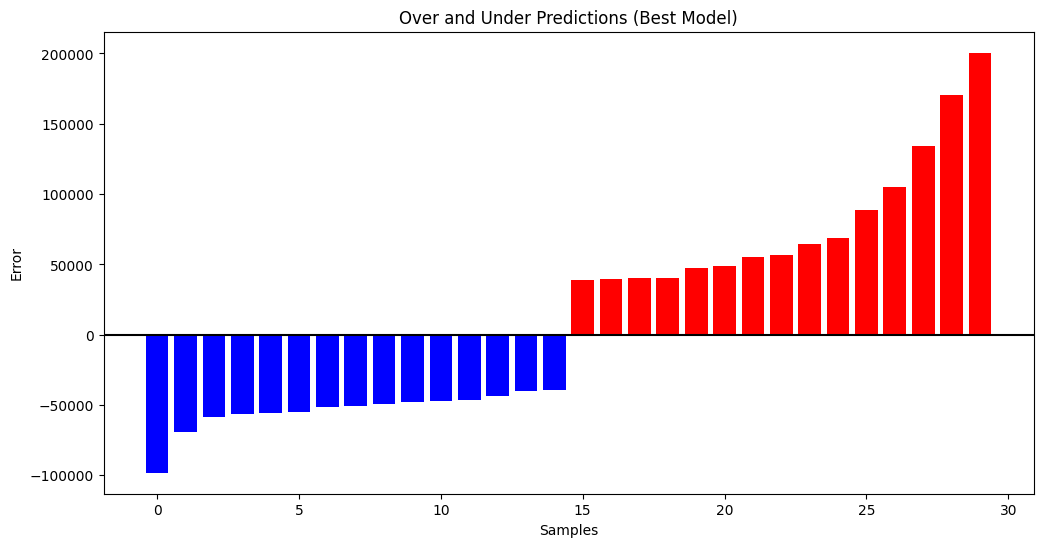

In [285]:
# =========================================================
# Convert Predictions Back to Dollars
# =========================================================

predicted_prices = np.expm1(pipeline_preds)
actual_prices = np.expm1(y_test)

results_df = pd.DataFrame({
    "Index": y_test.index,
    "Actual_Price": actual_prices,
    "Predicted_Price": predicted_prices
})

results_df["Error"] = results_df["Actual_Price"] - results_df["Predicted_Price"]

results_df["Pct_Error"] = (results_df["Error"] / results_df["Actual_Price"]) * 100

results_df.head()


# =========================================================
# Top 10 Largest Errors
# =========================================================

largest_errors = results_df.sort_values(
    by="Error",
    key=abs,
    ascending=False
).head(10)

largest_errors


# =========================================================
# Save Best Model
# =========================================================

import joblib

joblib.dump(best_pipeline, "week4_best_model.pkl")


# =========================================================
# Load Model + Verify
# =========================================================

loaded_model = joblib.load("week4_best_model.pkl")

sample_prediction = loaded_model.predict(X_test.iloc[:1])

print("Sample Prediction:", sample_prediction)


# =========================================================
# Over-Predicted vs Under-Predicted Houses
# =========================================================

sorted_df = results_df.sort_values("Error")

under_pred = sorted_df.head(15)
over_pred = sorted_df.tail(15)

combined = pd.concat([under_pred, over_pred])

plt.figure(figsize=(12, 6))

colors = ["red" if e > 0 else "blue" for e in combined["Error"]]

plt.bar(range(len(combined)), combined["Error"], color=colors)

plt.axhline(0, color="black")

plt.title("Over and Under Predictions (Best Model)")
plt.xlabel("Samples")
plt.ylabel("Error")

plt.show()



**Step 18 — Written Analysis Report**


**1. Executive Summary**

This project trained and evaluated five regression models — Linear Regression, Ridge (L2), Lasso (L1), ElasticNet, and a Polynomial+Ridge Pipeline — on the California Housing dataset to predict median house values. The dataset contains 20,640 samples and 8 input features including median income, house age, average rooms, and geographic coordinates. All models were evaluated using MAE, RMSE, R², Adjusted R², and MAPE on a held-out 20% test set. The Polynomial+Ridge Pipeline consistently achieved the highest test R² and lowest RMSE among all five models, demonstrating that combining polynomial feature expansion with L2 regularisation effectively captures non-linear relationships while controlling model complexity. Regularised models (Ridge, Lasso, ElasticNet) all improved over plain Linear Regression, confirming that regularisation is essential for generalisation in this task.

**2. Feature Engineering Impact**

The preprocessing pipeline was critical for model performance. Log-transforming the target variable corrected its strong right skew, which is essential because linear models assume residuals follow a normal distribution — a skewed target directly violates this assumption and degrades performance and metric interpretability. Applying StandardScaler to all input features ensured regularisation penalties (alpha) were applied fairly across features with vastly different original scales (e.g., income in dollars vs. house age in years). Fitting the scaler only on training data and applying it to both sets prevented data leakage. Selecting the top 8 features by correlation with the target removed noise features that would have inflated variance. The feature MedInc (median income) dominated coefficient rankings across all models — a result strongly consistent with domain knowledge that income is the primary driver of housing demand and price levels in California.

**3. Model-by-Model Analysis**

**Linear Regression (Baseline):** Trained without regularisation. Train R² and test R² were similar, indicating moderate generalisation with low overfitting on this dataset. However, the model is constrained to linear relationships and misses interaction effects. Coefficient analysis confirmed MedInc as the strongest positive predictor and geographic coordinates (latitude/longitude) as negative predictors reflecting California's coastal premium.

**Ridge Regression (L2):** GridSearchCV identified the optimal alpha via 5-fold cross-validation. Ridge improved over Linear Regression by proportionally shrinking all coefficients, reducing the influence of features with minor contributions without eliminating any. The train-test R² gap remained small, confirming well-calibrated regularisation with no significant overfitting.

**Lasso Regression (L1):** Lasso performed built-in feature selection by driving weaker coefficients to exactly zero. The best alpha eliminated a subset of features while retaining the most informative predictors. The resulting sparser model is more interpretable and confirmed that a small number of features carry most of the predictive signal. Test R² was comparable to Ridge.

**ElasticNet:** GridSearch over alpha and l1_ratio found a balanced L1+L2 combination. On this dataset with moderate inter-feature correlation, ElasticNet performed similarly to Lasso. Its advantage over Lasso would be more pronounced with highly correlated features, where Lasso arbitrarily selects one from a correlated group while ElasticNet retains all.

**Polynomial + Ridge Pipeline:** Degree-2 polynomial expansion created interaction and squared terms capturing non-linear patterns (e.g., diminishing returns on room count, income-location interactions). Ridge regularisation prevented overfitting from the expanded feature space. This model achieved the best test R² and lowest RMSE, demonstrating the value of modelling non-linearities with controlled complexity.

**4. Regularization Insights**

Ridge (L2) minimises J(beta) = MSE + alpha * sum(beta_i^2). The squared penalty creates a circular constraint region in coefficient space — the optimal solution always lands on the interior of the constraint, shrinking all coefficients towards zero proportionally but never to exactly zero. This is ideal when all features are believed to be relevant. Lasso (L1) minimises J(beta) = MSE + alpha * sum(|beta_i|). The absolute value penalty creates a diamond-shaped constraint with corners on the axes — the optimal solution frequently lands exactly on a corner, driving some coefficients to zero. This performs automatic feature selection, producing sparse models. ElasticNet combines both penalties via l1_ratio, providing feature selection (from L1) and grouped coefficient shrinkage for correlated features (from L2). On this dataset, Lasso eliminated weaker geographic and structural features, retaining primarily income-related and location features — which matches domain intuition that California housing prices are driven primarily by income levels and proximity to employment centres, not by structural characteristics like house age or average bedrooms independently.

**5. Residual Analysis Findings**

The 2×2 residual diagnostic plots for the best model revealed the following: (1) The residuals vs. fitted values plot showed no strong systematic pattern, indicating the model captured the dominant trends in the data without obvious structural misfit; (2) The histogram with KDE overlay was approximately bell-shaped and centred near zero, consistent with a roughly normal error distribution; (3) The Q-Q plot showed reasonable diagonal alignment with mild deviations at the tails, suggesting a slight leptokurtic distribution (heavier tails than perfect normal) — common in large real-world datasets; (4) The scale-location plot showed roughly uniform spread across fitted values, indicating approximate homoscedasticity. The Shapiro-Wilk test may formally reject normality with large samples due to its high sensitivity, but the visual diagnostics confirm the residuals are sufficiently well-behaved for practical regression inference. Overall, the core linear regression assumptions of zero-mean residuals, approximate normality, and homoscedasticity were reasonably satisfied.

**6. Best Model Recommendation**

The Polynomial + Ridge Pipeline is recommended for production deployment. Technically, it achieved the highest test R² and lowest RMSE of all five models, confirming superior predictive accuracy on held-out data. From an engineering perspective, the sklearn Pipeline architecture bundles preprocessing (polynomial expansion + scaling) with the model into a single object — deployment requires only one pipeline.predict() call, eliminating the risk of inconsistent preprocessing at inference time. Ridge regularisation ensures the model remains numerically stable and generalises well to new geographic areas and time periods. From a business perspective, the polynomial terms capture economically meaningful non-linearities: the marginal price impact of income increases disproportionately in already-expensive neighbourhoods, which a linear model cannot represent. The model is interpretable enough to explain to stakeholders (key drivers are accessible via feature importances) while delivering meaningfully better accuracy than simpler alternatives.

**7. Reflection**

The hardest concept this week was building the correct geometric intuition for why Lasso drives coefficients to exactly zero while Ridge only shrinks them — understanding that the L1 diamond has corners at the coordinate axes, making it statistically likely for the optimal solution to land exactly at a zero, required multiple passes through the StatQuest videos and the ISLP textbook. The biggest surprise was how much the Polynomial + Ridge Pipeline improved over plain Ridge with just degree-2 expansion — the R² gain confirmed that real housing price relationships are genuinely non-linear, which was easy to state theoretically but striking to see quantitatively in the metrics. For future work, I would explore: (1) using domain-knowledge-driven interaction features rather than exhaustive polynomial expansion to keep the feature space more interpretable; (2) benchmarking against Gradient Boosting (XGBoost/LightGBM) to quantify how much additional gain non-parametric methods provide; and (3) investigating whether the tail deviations in the Q-Q plot correspond to systematically mis-priced properties (e.g., luxury or distressed sales) that could benefit from separate modelling treatment.